## Тестовая работа по задаче классификации на датасете CUSTOMER CHURN PREDICTION из kagel

### Загрузка библиотек

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import pandas as pd
import numpy as np
import warnings
import shap
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

### Знакомство с данными 

In [5]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print(df.shape)
print(df.columns)

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Есть проблема с TotalCharges которй по идее должен быть в формате float возможно проблема связана с прбелами в данных

In [9]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Есть 11 пробелов в данных скорее всего связанные с tenure = 0 

In [11]:
df[df['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [12]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Избавились от 11 пробелов и привели TotalCharges к нормальному типу данных

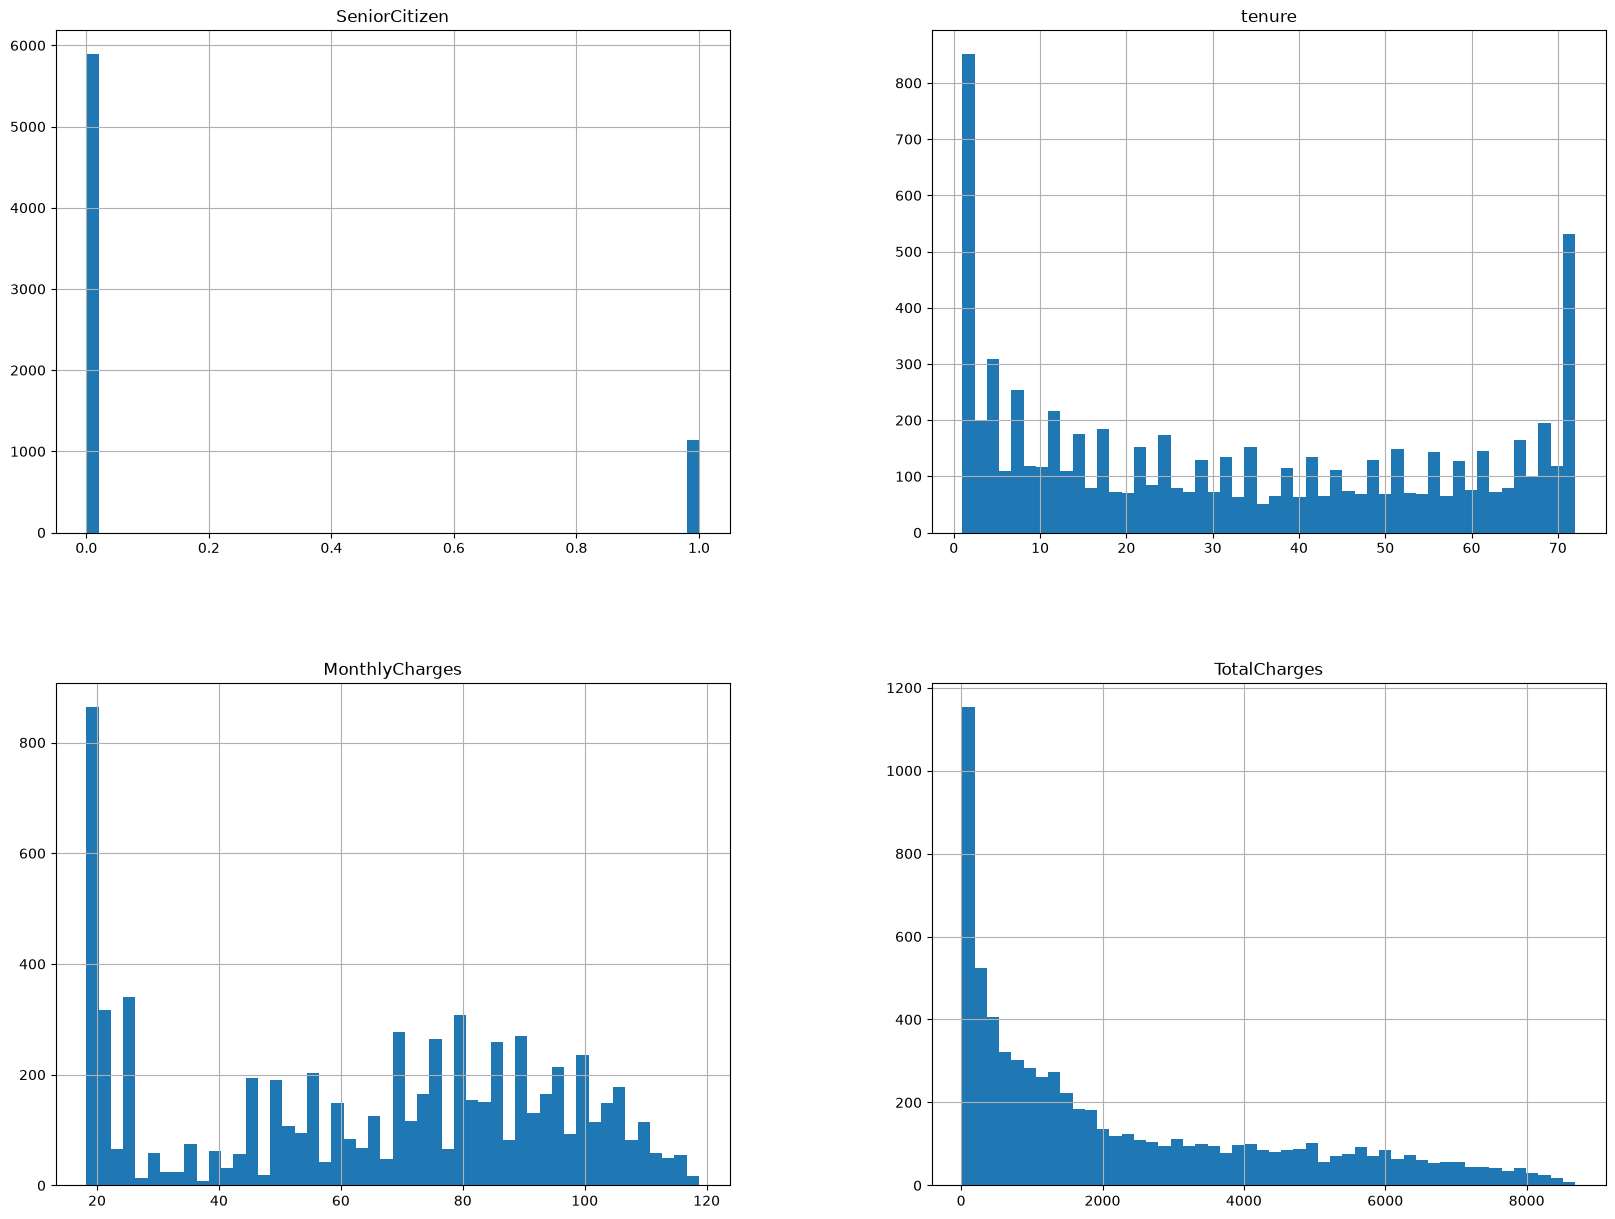

In [14]:
df.hist(bins=50, figsize=(20,15))
df_shape = df.shape[0]

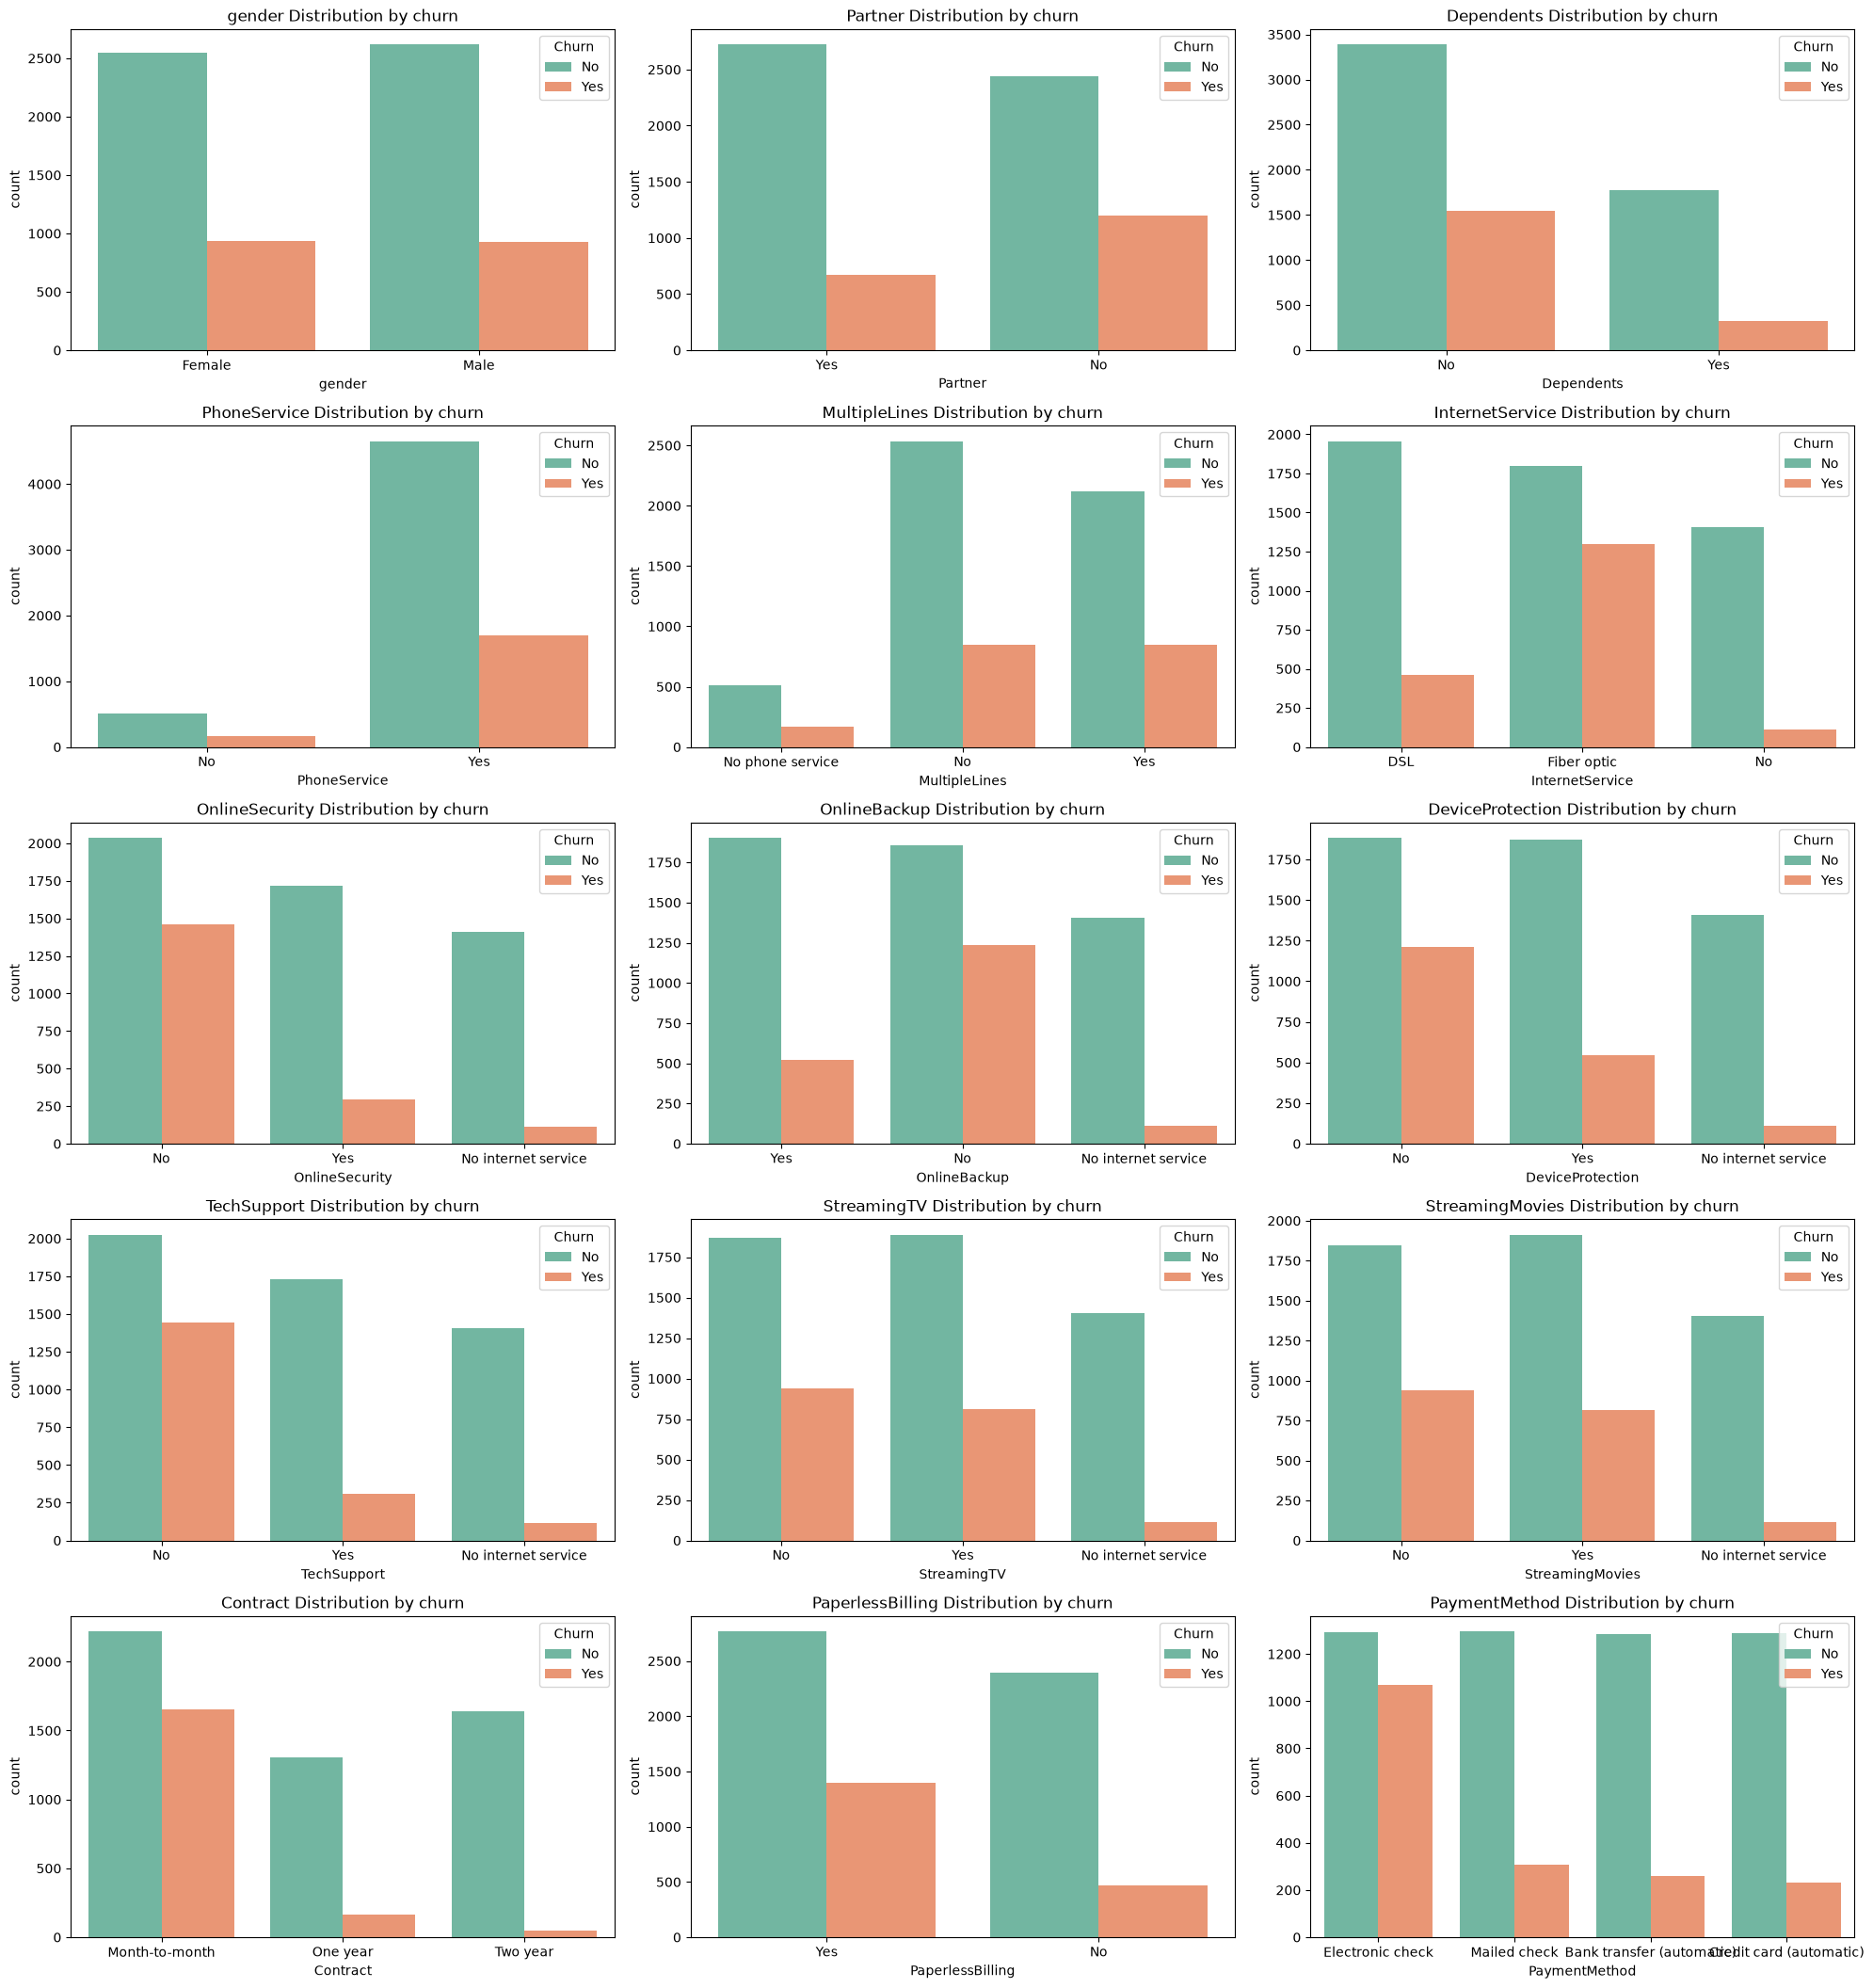

In [15]:
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(6, 3, i)
    sns.countplot(data=df, x=col, hue='Churn', palette='Set2')
    plt.title(f'{col} Distribution by churn')
    plt.tight_layout()

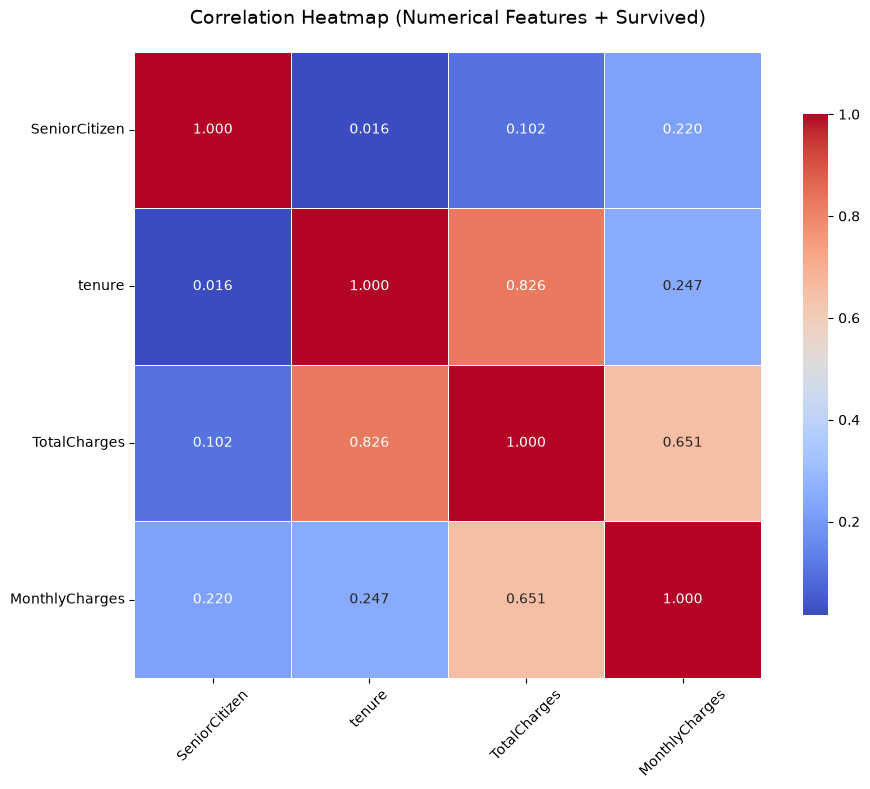

In [16]:

corr_matrix = df[['SeniorCitizen', 'tenure', 'TotalCharges', 'MonthlyCharges']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', 
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Numerical Features + Survived)', fontsize=14, pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Разделяем данные и обучаем модель 

In [17]:
drop_cols = ['customerID', 'Churn_numeric']  

feature_cols = [col for col in df.columns if col not in drop_cols + ['Churn']]

X = df[feature_cols]
y = df['Churn'].map({'Yes': 1, 'No': 0})


numeric_features = ['SeniorCitizen', 'tenure', 'TotalCharges', 'MonthlyCharges']


ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

X_cat_encoded = ohe.fit_transform(X[categorical_features])
X_cat_encoded_df = pd.DataFrame(X_cat_encoded, 
                                columns=ohe.get_feature_names_out(categorical_features),
                                index=X.index)

X_encoded = pd.concat([X[numeric_features].reset_index(drop=True), 
                       X_cat_encoded_df.reset_index(drop=True)], axis=1)

print(f"After One-Hot Encoding - Total Features: {X_encoded.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.15, random_state=42, stratify=y
)

print(f"Training Set   : {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test Set       : {X_test.shape[0]} rows  ({X_test.shape[0]/len(df)*100:.1f}%)")

# Churn ratio check (stratified hai ya nahi)
print(f"Train : {y_train.mean():.4f}")
print(f"Test  : {y_test.mean():.4f}")


After One-Hot Encoding - Total Features: 30
Training Set   : 5977 rows (85.0%)
Test Set       : 1055 rows  (15.0%)
Train : 0.2659
Test  : 0.2654


In [18]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np


In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("1. Training Baseline Model...")
dummy = DummyClassifier(strategy='most_frequent')
dummy_scores = cross_val_score(dummy, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Baseline ROC-AUC (CV): {dummy_scores.mean():.4f} ± {dummy_scores.std():.4f}")

# линейная регрессия 
print("\n2. Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Logistic Regression ROC-AUC (CV): {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")

# случайный лес
print("\n3. Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Random Forest ROC-AUC (CV): {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

# XGBoost 
print("\n4. Training XGBoost...")
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"XGBoost ROC-AUC (CV): {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}")


results = {
    'Model': ['Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC (CV Mean)': [dummy_scores.mean(), lr_scores.mean(), rf_scores.mean(), xgb_scores.mean()],
    'ROC-AUC (CV Std)': [dummy_scores.std(), lr_scores.std(), rf_scores.std(), xgb_scores.std()]
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON (5-Fold CV)")
print("="*60)
print(results_df)


1. Training Baseline Model...
Baseline ROC-AUC (CV): 0.5000 ± 0.0000

2. Training Logistic Regression...
Logistic Regression ROC-AUC (CV): 0.8471 ± 0.0117

3. Training Random Forest...
Random Forest ROC-AUC (CV): 0.8241 ± 0.0118

4. Training XGBoost...
XGBoost ROC-AUC (CV): 0.8281 ± 0.0152

MODEL PERFORMANCE COMPARISON (5-Fold CV)
                 Model  ROC-AUC (CV Mean)  ROC-AUC (CV Std)
0             Baseline             0.5000            0.0000
1  Logistic Regression             0.8471            0.0117
2        Random Forest             0.8241            0.0118
3              XGBoost             0.8281            0.0152


In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.15, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [21]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

print("Starting RandomizedSearchCV for XGBoost... (thoda time lega)")

xgb = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,                   
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"Best ROC-AUC Score: {random_search.best_score_:.4f}")
for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")


best_model = random_search.best_estimator_


y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_proba)
gini = 2 * val_roc_auc - 1


print(f"\nAccuracy     : {val_accuracy:.4f}")
print(f"Precision    : {val_precision:.4f}")
print(f"Recall       : {val_recall:.4f}")
print(f"F1-Score     : {val_f1:.4f}")
print(f"ROC-AUC      : {val_roc_auc:.4f}")
print(f"Gini         : {gini:.4f}")

Starting RandomizedSearchCV for XGBoost... (thoda time lega)
Fitting 5 folds for each of 30 candidates, totalling 150 fits


Best ROC-AUC Score: 0.8498
   subsample: 0.7
   n_estimators: 100
   min_child_weight: 5
   max_depth: 3
   learning_rate: 0.1
   gamma: 0.1
   colsample_bytree: 0.7

Accuracy     : 0.8065
Precision    : 0.6667
Recall       : 0.5429
F1-Score     : 0.5984
ROC-AUC      : 0.8495
Gini         : 0.6991


Classification Report on Test Set:
              precision    recall  f1-score   support

    No Churn       0.83      0.87      0.85       388
       Churn       0.60      0.51      0.55       140

    accuracy                           0.78       528
   macro avg       0.71      0.69      0.70       528
weighted avg       0.77      0.78      0.77       528



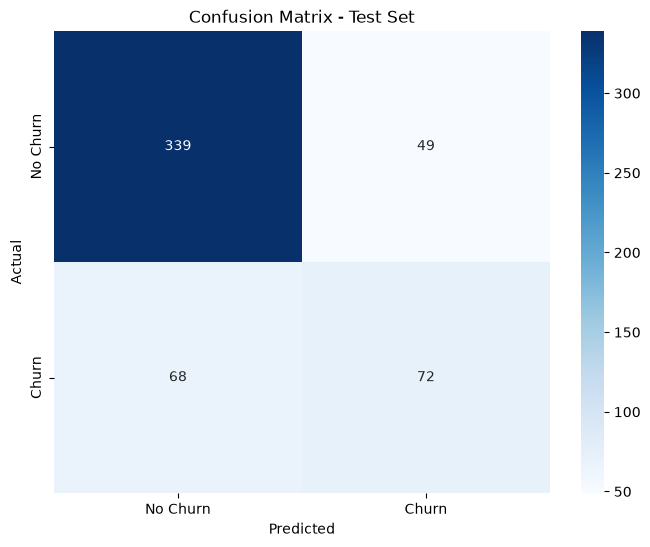

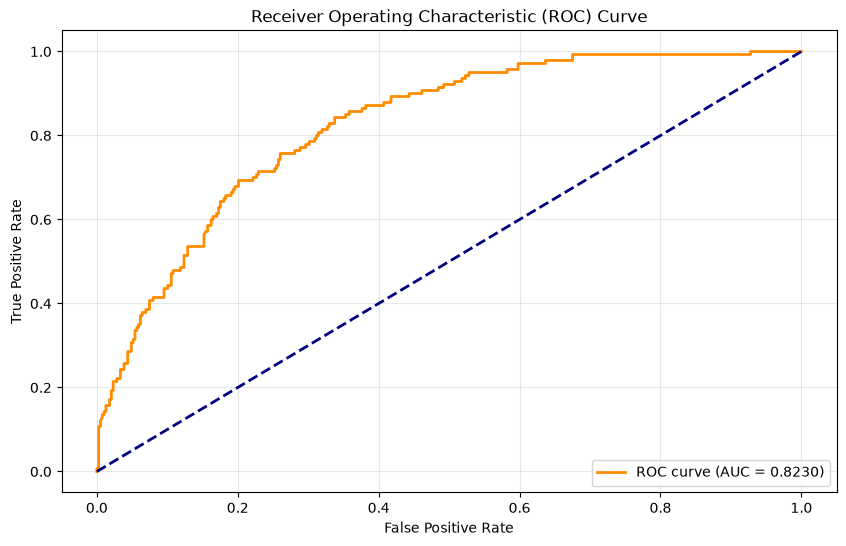

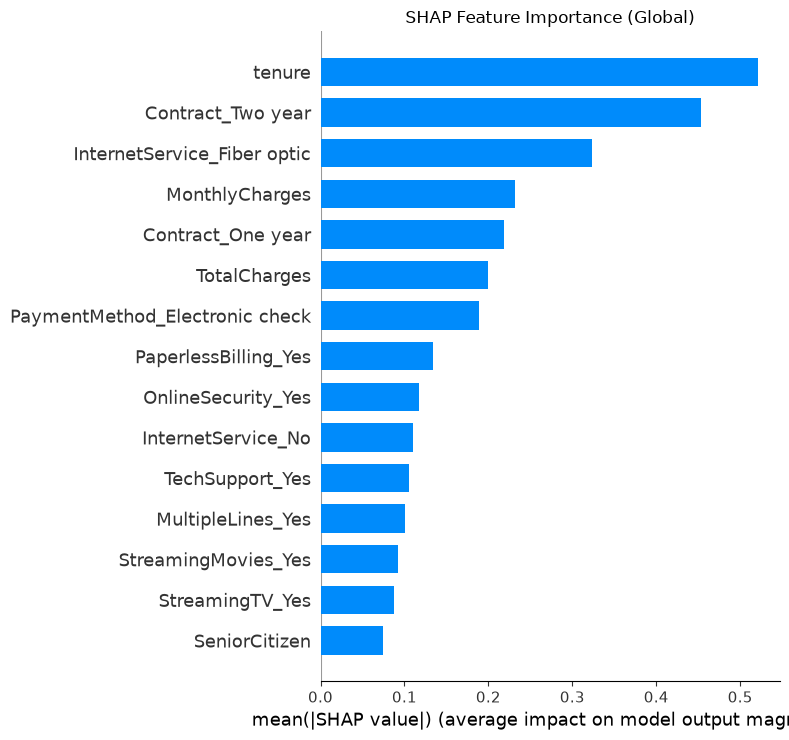

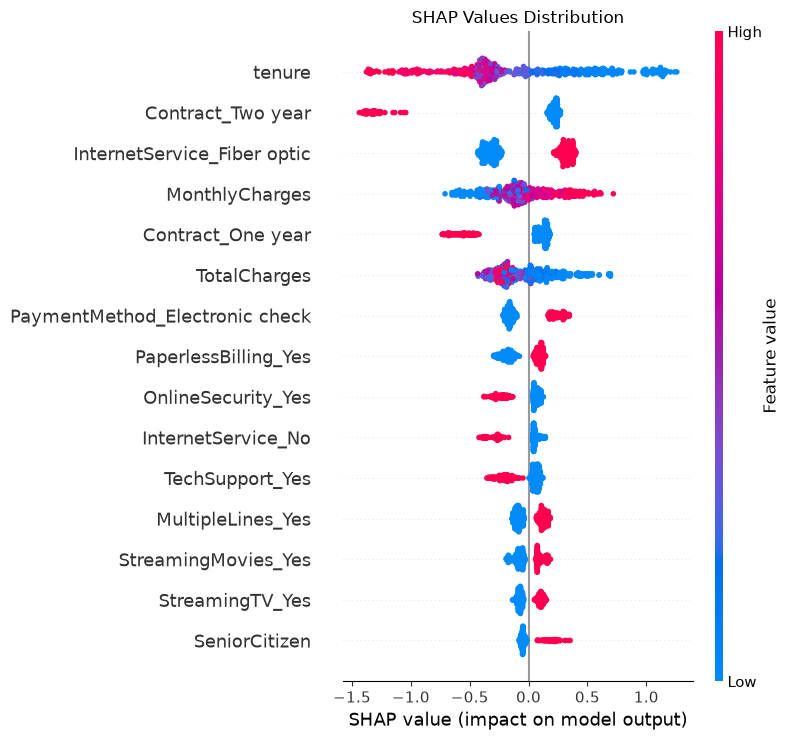

In [22]:
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]


print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Feature Importance (Global)")
plt.tight_layout()
plt.show()

# SHAP Summary (beeswarm plot)
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("SHAP Values Distribution")
plt.tight_layout()
plt.show()

In [23]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
    'scale_pos_weight': [1.0, 1.5, 1.6, 2.0, 3.0] 
}


xgb = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,                   
    scoring='recall',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")


best_reacll_model = random_search.best_estimator_
best_recall_model = best_reacll_model


y_val_pred = best_reacll_model.predict(X_val)
y_val_proba = best_reacll_model.predict_proba(X_val)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_proba)
gini = 2 * val_roc_auc - 1


print(f"\nAccuracy     : {val_accuracy:.4f}")
print(f"Precision    : {val_precision:.4f}")
print(f"Recall       : {val_recall:.4f}")
print(f"F1-Score     : {val_f1:.4f}")
print(f"ROC-AUC      : {val_roc_auc:.4f}")
print(f"Gini         : {gini:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
   subsample: 1.0
   scale_pos_weight: 2.0
   n_estimators: 200
   min_child_weight: 5
   max_depth: 5
   learning_rate: 0.01
   gamma: 0.1
   colsample_bytree: 0.8

Accuracy     : 0.7913
Precision    : 0.5815
Recall       : 0.7643
F1-Score     : 0.6605
ROC-AUC      : 0.8469
Gini         : 0.6939


### Сравнение best_model vs best_recall_model по гипотетической прибыли

Идея: считаем ожидаемую прибыль на тестовой выборке через бизнес-допущения.

Допущения (можно менять):
- customer_ltv — сколько денег в среднем теряем, если клиент ушёл;
- intervention_cost — стоимость удерживающего контакта/оффера на одного клиента;
- retention_success_prob — вероятность удержать churn-клиента, если мы его правильно нашли.

Таким образом сравниваем модели не только по recall/roc-auc, а по ожидаемому бизнес-эффекту.
Так как значения взяты на угад прибыль может ухадить в отрицательные значения, но нам выжем сам факт какая модель будет лучше

In [24]:
import numpy as np
import pandas as pd

# --- Бизнес-допущения (подставьте свои значения) ---
customer_ltv = 500.0             # ожидаемая потеря, если клиент ушел
intervention_cost = 20.0         # стоимость удерживающего контакта на одного клиента
retention_success_prob = 0.5    # P(удержали | клиент склонен к оттоку и модель его нашла)
threshold = 0.5                  # порог классификации по вероятности


def expected_profit(y_true, y_pred, ltv, cost, p_save):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tn = np.sum((y_true == 0) & (y_pred == 0))

    profit_tp = tp * (p_save * ltv - cost)
    profit_fp = fp * (-cost)
    profit_fn = fn * (-ltv)
    profit_tn = 0.0

    total_profit = profit_tp + profit_fp + profit_fn + profit_tn
    avg_profit = total_profit / len(y_true)

    return {
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "Total Profit": float(total_profit),
        "Profit per Client": float(avg_profit),
    }


models_to_compare = {
    "best_model (настройка по ROC-AUC)": best_model,
    "best_recall_model (настройка по Recall)": best_recall_model,
}

rows = []
for name, model in models_to_compare.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    metrics = expected_profit(y_test, y_pred, customer_ltv, intervention_cost, retention_success_prob)
    metrics["Model"] = name
    metrics["Threshold"] = threshold
    rows.append(metrics)

profit_df = pd.DataFrame(rows)[[
    "Model", "Threshold", "TP", "FP", "FN", "TN", "Total Profit", "Profit per Client"
]].sort_values("Total Profit", ascending=False)

print("=" * 80)
print("СРАВНЕНИЕ ПРИБЫЛИ: best_model vs best_recall_model")
print("=" * 80)
display(profit_df.round(2))

winner = profit_df.iloc[0]
print(f"Победитель по ожидаемой суммарной прибыли: {winner['Model']}")

СРАВНЕНИЕ ПРИБЫЛИ: best_model vs best_recall_model


,Model,Threshold,TP,FP,FN,TN,Total Profit,Profit per Client
1,best_recall_model (настройка по Recall),0.5,100,94,40,294,1120.0,2.12
0,best_model (настройка по ROC-AUC),0.5,72,49,68,339,-18420.0,-34.89


Победитель по ожидаемой суммарной прибыли: best_recall_model (настройка по Recall)
